# Cat vs. Dog Image Classifier

Train and evaluate a convolutional neural network (CNN) to classify images as cats or dogs. The labels are `0 = cat` and `1 = dog`. This notebook reuses the validated data pipeline and CNN from `src/cat_dog_cnn`.

In Jupyter, select the **Python (cat-dog-cnn)** kernel. Install the project dependencies first with `python -m pip install -r requirements.txt` from the project folder. The notebook locates the project when started from the project folder or one of its subfolders.

The default run uses a balanced 2,000-image sample and an ImageNet-pretrained MobileNetV2 for a quick, strong baseline. For best accuracy, change `SAMPLE_SIZE` to `None` to use all 25,000 images; full training can take a while on CPU.

## 1. Imports and configuration

In [1]:
import sys
from pathlib import Path

current_dir = Path.cwd().resolve()
PROJECT_ROOT = next(
    (
        candidate
        for candidate in (current_dir, *current_dir.parents)
        if (candidate / "cat_dog.csv").is_file()
        and (candidate / "src" / "cat_dog_cnn").is_dir()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find cat_dog.csv and src/cat_dog_cnn. "
        "Open Jupyter from the cat-dog-cnn project folder."
    )
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from cat_dog_cnn.data import load_metadata, make_dataset, resolve_image_dir, split_metadata, validate_images
from cat_dog_cnn.model import build_model
from cat_dog_cnn.predict import predict_image

CSV_PATH = PROJECT_ROOT / "cat_dog.csv"
IMAGE_DIR = resolve_image_dir(csv_path=CSV_PATH)
IMAGE_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 6
SAMPLE_SIZE = 2000  # Set to None to train on all labeled images.
SEED = 42
MODEL_PATH = PROJECT_ROOT / "models" / "cat_dog_cnn.keras"

tf.keras.utils.set_random_seed(SEED)
print(f"Labels: {CSV_PATH}")
print(f"Images: {IMAGE_DIR}")
print(f"TensorFlow: {tf.__version__}")


Labels: C:\Users\Dr. Shubham Khairnar\Desktop\New folder\mnist-cat-dog-cnn\cat_dog.csv
Images: C:\Users\Dr. Shubham Khairnar\Desktop\New folder\mnist-cat-dog-cnn\archive (1)\cat_dog
TensorFlow: 2.15.1


## 2. Load and inspect the labels

The CSV contains image filenames and binary labels. This validates the schema, confirms that referenced image files exist, and checks the class balance.

In [2]:
metadata = load_metadata(CSV_PATH, IMAGE_DIR)
validate_images(metadata, check_integrity=False)

print(f"Labeled images: {len(metadata):,}")
display(metadata.head())
display(
    metadata["labels"]
    .map({0: "cat", 1: "dog"})
    .value_counts()
    .rename_axis("class")
    .to_frame("image_count")
)

Labeled images: 25,000


,image,labels,path
0,dog.11289.jpg,1,C:\Users\Dr. Shubham Khairnar\Desktop\New fold...
1,cat.10836.jpg,0,C:\Users\Dr. Shubham Khairnar\Desktop\New fold...
2,cat.7970.jpg,0,C:\Users\Dr. Shubham Khairnar\Desktop\New fold...
3,cat.2212.jpg,0,C:\Users\Dr. Shubham Khairnar\Desktop\New fold...
4,dog.2653.jpg,1,C:\Users\Dr. Shubham Khairnar\Desktop\New fold...


,image_count
class,
dog,12500
cat,12500


## 3. Preview sample images

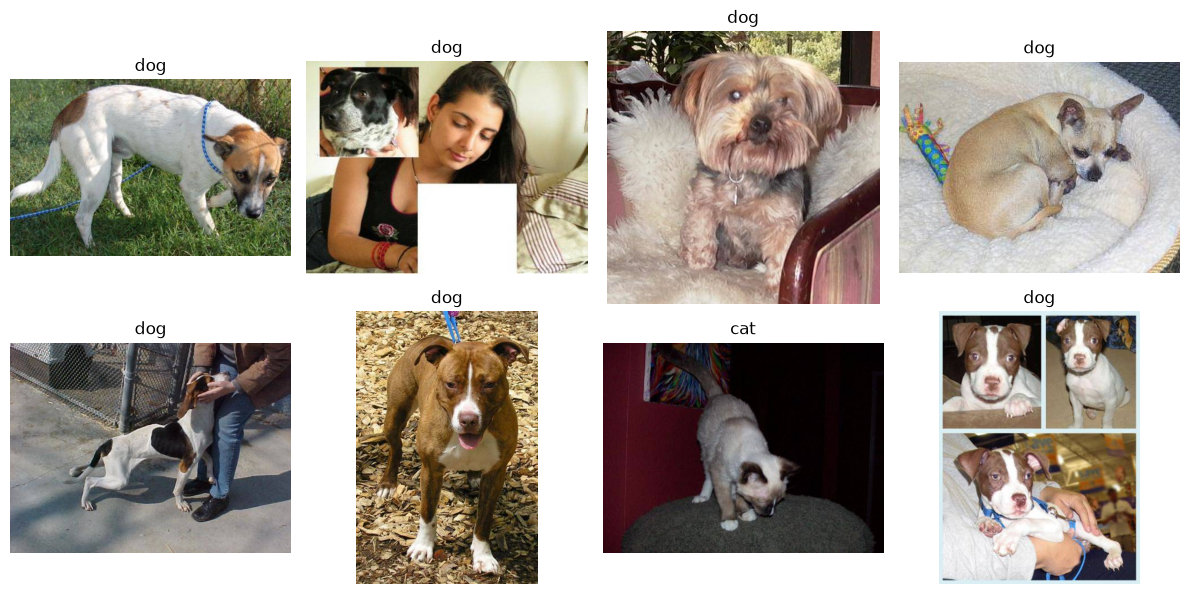

In [3]:
preview = metadata.sample(n=min(8, len(metadata)), random_state=SEED).reset_index(drop=True)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for axis, row in zip(axes.flat, preview.itertuples()):
    with Image.open(row.path) as image:
        axis.imshow(image.convert("RGB"))
    axis.set_title("dog" if row.labels == 1 else "cat")
    axis.axis("off")
plt.tight_layout()
plt.show()

## 4. Prepare train, validation, and test sets

The default balanced 2,000-image sample is enough to demonstrate transfer learning with the pretrained CNN. Set `SAMPLE_SIZE = None` above to train on the full dataset for best accuracy. The held-out test set is not used during model fitting.

In [4]:
if SAMPLE_SIZE is not None:
    if SAMPLE_SIZE < 4 or SAMPLE_SIZE % 2:
        raise ValueError("SAMPLE_SIZE must be an even number of at least 4, or None.")
    per_class = SAMPLE_SIZE // 2
    counts = metadata["labels"].value_counts()
    if any(counts.get(label, 0) < per_class for label in (0, 1)):
        raise ValueError(f"Not enough examples to sample {per_class} images from each class.")
    training_metadata = (
        metadata.groupby("labels", group_keys=False)
        .sample(n=per_class, random_state=SEED)
        .reset_index(drop=True)
    )
else:
    training_metadata = metadata

train_frame, validation_frame, test_frame = split_metadata(training_metadata, seed=SEED)
print(
    f"Train: {len(train_frame):,} | Validation: {len(validation_frame):,} "
    f"| Test: {len(test_frame):,}"
)

train_dataset = make_dataset(
    train_frame, IMAGE_SIZE, BATCH_SIZE, training=True, seed=SEED
)
validation_dataset = make_dataset(validation_frame, IMAGE_SIZE, BATCH_SIZE)
test_dataset = make_dataset(test_frame, IMAGE_SIZE, BATCH_SIZE)

Train: 1,400 | Validation: 300 | Test: 300


## 5. Build and train the CNN

The model uses an ImageNet-pretrained MobileNetV2 backbone, on-the-fly augmentation, and a binary classification head. The first run downloads the pretrained weights if needed. The checkpoint with the best validation AUC is saved under `models/`.

In [5]:
model = build_model(IMAGE_SIZE)
model.summary()

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=5, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc", mode="max", factor=0.5, patience=2, min_lr=1e-6, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        str(MODEL_PATH), monitor="val_auc", mode="max", save_best_only=True
    ),
]

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
)



Model: "cat_dog_cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 augmentation (Sequential)   (None, 128, 128, 3)       0         
                                                                 
 rescaling (Rescaling)       (None, 128, 128, 3)       0         
                                                                 
 mobilenetv2_1.00_128 (Func  (None, 4, 4, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dropout (Dropout)           (None, 1280)            

## 6. Review training progress

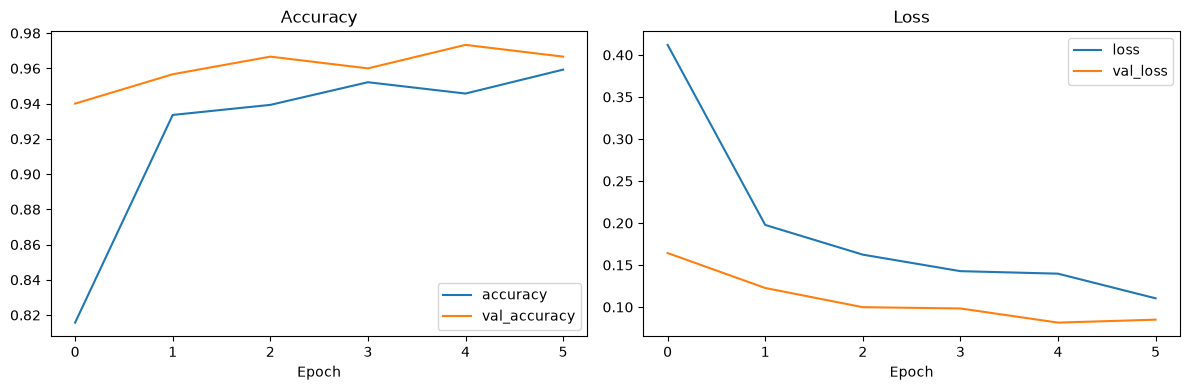

In [6]:
history_frame = pd.DataFrame(history.history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history_frame[["accuracy", "val_accuracy"]].plot(ax=axes[0])
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
history_frame[["loss", "val_loss"]].plot(ax=axes[1])
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
plt.tight_layout()
plt.show()

## 7. Evaluate on the held-out test set

The report uses `0 = cat` and `1 = dog`. The confusion matrix uses the same order for rows (actual) and columns (predicted).

In [7]:
test_loss, test_accuracy, test_auc = model.evaluate(test_dataset, verbose=0)
probabilities = model.predict(test_dataset, verbose=0).ravel()
actual = test_frame["labels"].to_numpy()
predicted = (probabilities >= 0.5).astype("int32")

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test ROC-AUC: {roc_auc_score(actual, probabilities):.4f}")
print(classification_report(actual, predicted, target_names=["cat", "dog"], zero_division=0))
print("Confusion matrix (actual rows, predicted columns):")
print(confusion_matrix(actual, predicted))

Test loss: 0.0878
Test accuracy: 0.9600
Test ROC-AUC: 0.9960
              precision    recall  f1-score   support

         cat       0.97      0.95      0.96       150
         dog       0.95      0.97      0.96       150

    accuracy                           0.96       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.96      0.96      0.96       300

Confusion matrix (actual rows, predicted columns):
[[143   7]
 [  5 145]]


## 8. Predict one image

This uses the saved model and reports the predicted class with its confidence.

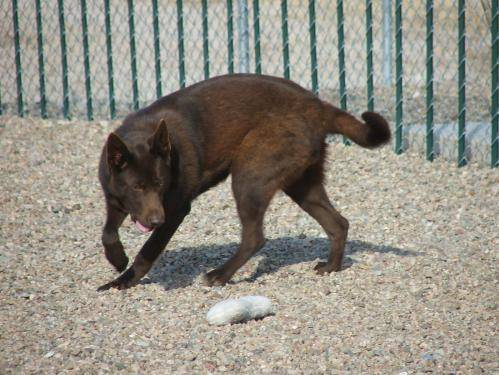

Actual: dog | Predicted: dog (79.2% confidence)
Saved model: C:\Users\Dr. Shubham Khairnar\Desktop\New folder\mnist-cat-dog-cnn\models\cat_dog_cnn.keras


In [8]:
example = test_frame.iloc[0]
predicted_class, confidence = predict_image(example["path"], MODEL_PATH)
actual_class = "dog" if example["labels"] == 1 else "cat"

with Image.open(example["path"]) as image:
    display(image.convert("RGB"))
print(f"Actual: {actual_class} | Predicted: {predicted_class} ({confidence:.1%} confidence)")
print(f"Saved model: {MODEL_PATH}")